# Simulation Method Validation and PSS Window Sticker

This notebook is analysis-only. Run `examples/IBM_QAOA/run_job.sh` or `examples/IBM_QAOA/run_job_small.sh` first to generate the IBM QAOA campaign artifacts, then load and analyze them here.


In [1]:
# Analysis imports
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import pandas as pd
from IPython.display import display

sys.path.insert(0, os.path.abspath('..'))

from src.utils import (
    apply_shared_approx_axis,
    concat_summary,
    cross_strategy_envelope,
    curve_from_training_summary,
    curve_from_window_summary,
    curve_label,
    load_multi_strategy_summaries,
    plot_exact_resource_model_predictions,
    plot_method_curves,
    plot_parameter_prescriptions_by_resource,
    prepare_monotone_curve,
    save_current_plot,
    shared_approx_ylim as compute_shared_approx_ylim,
    shared_approx_yticks as compute_shared_approx_yticks,
)
from src.simulation_validation import (
    build_resource_frontier_from_exact_points,
    build_binned_budget_dataset,
    build_strategy_budget_summary,
    fit_exact_resource_models,
    run_stochastic_benchmark_pss,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

%load_ext autoreload
%autoreload 2

In [2]:
# Analysis configuration
GRAPH_TYPE = 'heavy_hex'
NUM_NODES = 144
RESULT_TAG = 'heavy_hex_144_FA_PP_opt_p5_expanded'

BS_BOOTSTRAP_RANGE = range(10, 51, 10)
TRAIN_TEST_SPLIT_FRACTION = 0.5

OUTPUT_ROOT = Path(f'../results/pss_window_sticker/{RESULT_TAG}').resolve()
WINDOW_STICKER_DIR = OUTPUT_ROOT / 'window_sticker'
EXACT_RESOURCE_ROOT = OUTPUT_ROOT / 'exact_resource'
EXACT_WINDOW_STICKER_DIR = EXACT_RESOURCE_ROOT / 'window_sticker'
AUGMENTED_PROXY_WINDOW_STICKER_DIR = OUTPUT_ROOT / 'augmented_proxy_window_sticker'
PLOT_DIR = OUTPUT_ROOT / 'notebook_plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

FRONTIER_PATH = OUTPUT_ROOT / 'pss_exp_raw_frontier.pkl'
FA_EXACT_PATH = OUTPUT_ROOT / 'fa_raw_points.pkl'
PT_EXACT_PATH = OUTPUT_ROOT / 'pt_raw_points.pkl'
TRAIN_SPECS_PATH = OUTPUT_ROOT / 'train_instance_specs.csv'
TEST_SPECS_PATH = OUTPUT_ROOT / 'test_instance_specs.csv'
CODEBOOK_PATH = OUTPUT_ROOT / 'ws_codebooks.json'
FRONTIER_PREVIEW_PATH = OUTPUT_ROOT / 'frontier_preview.csv'
FRONTIER_SUMMARY_PATH = OUTPUT_ROOT / 'frontier_group_summary.csv'


In [3]:
# Load campaign artifacts generated by the terminal script
required_paths = [FA_EXACT_PATH, CODEBOOK_PATH]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    missing = '\n'.join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        'Missing campaign artifacts. Run examples/IBM_QAOA/run_job.sh or '
        'examples/IBM_QAOA/run_job_small.sh first:\n' + missing
    )

exact_frames = [pd.read_pickle(FA_EXACT_PATH)]
if PT_EXACT_PATH.exists():
    exact_frames.append(pd.read_pickle(PT_EXACT_PATH))
exact_df = pd.concat(exact_frames, ignore_index=True)
ws_codebooks = json.loads(CODEBOOK_PATH.read_text(encoding='utf-8'))

stored_frontier_df = pd.read_pickle(FRONTIER_PATH) if FRONTIER_PATH.exists() else pd.DataFrame()
budget_grid_points = int(stored_frontier_df['T'].nunique()) if not stored_frontier_df.empty else 1000

# Augmented proxy: keep the proxy dependence on N, M, Q, but add the measured total
# training/iteration wallclock as a per-setting offset. This does not require rerunning
# the experiment because all terms are already stored in the exact-point data.
exact_df['T_proxy_aug'] = (
    pd.to_numeric(exact_df['training_cost_proxy'], errors='coerce').fillna(0.0)
    + pd.to_numeric(exact_df['sampling_cost_proxy'], errors='coerce').fillna(0.0)
    + pd.to_numeric(exact_df['runtime_train_wallclock'], errors='coerce').fillna(0.0)
)

exact_frontier_df = build_resource_frontier_from_exact_points(
    exact_df,
    codebooks=ws_codebooks,
    num_bins=budget_grid_points,
    budget_col='T_exact',
    scale='log',
)
augmented_proxy_frontier_df = build_resource_frontier_from_exact_points(
    exact_df,
    codebooks=ws_codebooks,
    num_bins=budget_grid_points,
    budget_col='T_proxy_aug',
    scale='log',
)

train_specs_df = pd.read_csv(TRAIN_SPECS_PATH) if TRAIN_SPECS_PATH.exists() else pd.DataFrame()
test_specs_df = pd.read_csv(TEST_SPECS_PATH) if TEST_SPECS_PATH.exists() else pd.DataFrame()
frontier_preview_df = augmented_proxy_frontier_df.head(30).copy()
frontier_summary_df = augmented_proxy_frontier_df.groupby(['split', 'strategy'], as_index=False).agg(
    n_rows=('instance', 'size'),
    min_T=('T', 'min'),
    max_T=('T', 'max'),
    best_response=('BestApproximationRatio', 'max'),
)

print('Loaded campaign from:', OUTPUT_ROOT)
print('Exact rows:', len(exact_df))
print('Exact binned frontier rows:', len(exact_frontier_df))
print('Exact budget bins used:', exact_frontier_df['T'].nunique())
print('Augmented proxy binned frontier rows:', len(augmented_proxy_frontier_df))
print('Augmented proxy budget bins used:', augmented_proxy_frontier_df['T'].nunique())
print('Strategies:', sorted(augmented_proxy_frontier_df['strategy'].dropna().unique()))
print('Splits:', sorted(augmented_proxy_frontier_df['split'].dropna().unique()))


Loaded campaign from: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded
Exact rows: 12240
Exact binned frontier rows: 12240
Exact budget bins used: 552
Strategies: ['FA_PP_opt']
Splits: ['test', 'train']


In [4]:
# Quick artifact preview
display(train_specs_df.head(10))
display(test_specs_df.head(10))
display(frontier_preview_df)
display(frontier_summary_df)


,graph_type,num_nodes,instance,degree,swap_layers,er_probability,graph_path,minmax_path,split,source
0,heavy_hex,144,100,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
1,heavy_hex,144,101,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
2,heavy_hex,144,102,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
3,heavy_hex,144,103,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
4,heavy_hex,144,104,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
5,heavy_hex,144,105,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
6,heavy_hex,144,106,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
7,heavy_hex,144,107,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
8,heavy_hex,144,108,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train
9,heavy_hex,144,109,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/stochastic-bench...,/mnt/c/Users/rames102/Desktop/stochastic-bench...,train,generated_train


,graph_type,num_nodes,instance,degree,swap_layers,er_probability,graph_path,minmax_path,split,source
0,heavy_hex,144,0,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
1,heavy_hex,144,1,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
2,heavy_hex,144,2,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
3,heavy_hex,144,3,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
4,heavy_hex,144,4,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
5,heavy_hex,144,5,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
6,heavy_hex,144,6,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
7,heavy_hex,144,7,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
8,heavy_hex,144,8,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test
9,heavy_hex,144,9,NaN,NaN,NaN,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,/mnt/c/Users/rames102/Desktop/QAOA-Parameter-S...,test,repo_test


,graph_type,num_nodes,instance,instance_id,split,source,p,strategy,strategy_family,strategy_runtime_label,simulation_method,N,M,classical_setup_cost,training_cost,sampling_cost,T_exact,classical_setup_cost_proxy,training_cost_proxy,sampling_cost_proxy,T_exact_proxy,num_objective_evaluations,total_training_shots,runtime_train_wallclock,runtime_sample_wallclock,Q,counts,best_bitstring,best_found_value,BestApproximationRatio,Approximation_Ratio,budget_bin,budget_left,budget_right,T,resource,selected_exact_T,selected_exact_T_proxy,budget_distance,strategy_code,simulation_code,train
0,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,10,10,0.0,45.646189,0.944788,46.590976,0.0,0.000250,0.00050,0.000750,13,130,45.646189,0.944788,200,{'11011111000011010010101101001001001011101101...,0100000000001111111101001011000100110100011000...,49.618521,0.840171,0.840171,26,46.369669,46.638530,46.503905,46.503905,46.590976,0.000750,0.0,0.0,0.0,1
1,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,20,10,0.0,105.080708,1.225633,106.306341,0.0,0.000500,0.00050,0.001000,26,260,105.080708,1.225633,200,{'11011110011011001011110101011111011101000011...,0101100110001101001100111000111101011010001110...,55.486137,0.886811,0.886811,169,105.995224,106.609806,106.302071,106.302071,106.306341,0.001000,0.0,0.0,0.0,1
2,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,50,10,0.0,226.879621,0.922751,227.802371,0.0,0.001250,0.00050,0.001750,57,570,226.879621,0.922751,200,{'01011011101100101100011001001111110010010011...,0101101010101110101010111101001001101001001101...,47.743757,0.825269,0.825269,301,227.362685,228.680980,228.020880,228.020880,227.802371,0.001750,0.0,0.0,0.0,1
3,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,75,10,0.0,318.400722,0.885829,319.286551,0.0,0.001875,0.00050,0.002375,83,830,318.400722,0.885829,200,{'10111000000001000010010010110011110001110011...,0010011011110001010010000110001111000010001011...,47.365264,0.822260,0.822260,359,317.942653,319.786149,318.863069,318.863069,319.286551,0.002375,0.0,0.0,0.0,1
4,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,100,10,0.0,430.225393,1.112982,431.338375,0.0,0.002500,0.00050,0.003000,109,1090,430.225393,1.112982,200,{'11000100000001010001001111001101001111010110...,1101110000010001010101001110111011011101000010...,46.253817,0.813426,0.813426,411,429.450652,431.940694,430.693873,430.693873,431.338375,0.003000,0.0,0.0,0.0,1
5,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,10,50,0.0,56.370564,1.115766,57.486330,0.0,0.001250,0.00050,0.001750,13,650,56.370564,1.115766,200,{'01000000100110100110000000000010000001111001...,0011101111101110001000111010000011111001110011...,52.152567,0.860313,0.860313,63,57.429580,57.762569,57.595834,57.595834,57.486330,0.001750,0.0,0.0,0.0,1
6,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,20,50,0.0,114.965631,1.232290,116.197921,0.0,0.002500,0.00050,0.003000,26,1300,114.965631,1.232290,200,{'01000100000100000000110001100110100010000011...,1010010111101111001000110001000011001111110001...,51.123698,0.852135,0.852135,184,115.597682,116.267941,115.932327,115.932327,116.197921,0.003000,0.0,0.0,0.0,1
7,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,50,50,0.0,257.228827,1.218947,258.447774,0.0,0.006250,0.00050,0.006750,57,2850,257.228827,1.218947,200,{'00100000110001010101101111000010101100111000...,1100000110111000010001000111111000110111000100...,49.736662,0.841110,0.841110,323,258.201051,259.698153,258.948520,258.948520,258.447774,0.006750,0.0,0.0,0.0,1
8,heavy_hex,144,100,100,train,generated_train,5,FA_PP_opt,FA,FA_PP_opt_5,MPSAer,75,50,0.0,363.494788,0.984605,364.479394,0.0,0.009375,0.00050,0.009875,83,4150,363.494788,0.984605,200,{'00111100011110001011111100110001000111000101...,1011101001110011100111111000001011110111001010...,50.906693

,split,strategy,n_rows,min_T,max_T,best_response
0,test,FA_PP_opt,4080,42.150709,1903.086336,0.906866
1,train,FA_PP_opt,8160,40.013560,12898.867340,0.924205


In [5]:
# Inspect the available encoded metadata before running stochastic-benchmark
display(pd.DataFrame({
    'strategy_code': list(ws_codebooks.get('strategy', {}).keys()),
    'strategy_name': list(ws_codebooks.get('strategy', {}).values()),
}))
display(pd.DataFrame({
    'simulation_code': list(ws_codebooks.get('simulation', {}).keys()),
    'simulation_name': list(ws_codebooks.get('simulation', {}).values()),
}))


,strategy_code,strategy_name
0,0,FA_PP_opt


,simulation_code,simulation_name
0,0,MPSAer


,model,expression,alpha,beta,power_slope
0,through_origin,T_exact ≈ 2729.51 · T_proxy,2729.514674,0.00000,1.00000
1,affine,T_exact ≈ 1235.17 · T_proxy + 224.089,1235.173275,224.08913,1.00000
2,power_law,T_exact ≈ 643.329 · T_proxy^0.27952,643.328706,0.00000,0.27952


Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/proxy_vs_exact_calibration.pdf and .png


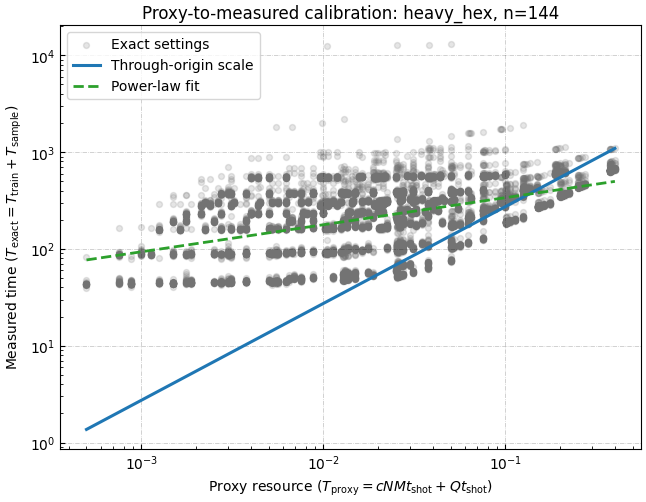

Recommended global scale to map proxy onto measured-time units:
  T_exact ≈ 2729.51 · T_proxy


,model,expression,n_train,n_test,train_log10_rmse,train_median_factor_error,train_p90_factor_error,train_log_r2,test_log10_rmse,test_median_factor_error,test_p90_factor_error,test_log_r2
0,interaction_n_m_q,T_exact = 13.7558 + 3.55874 N + 0.00210949 M +...,408,408,0.018885,1.008024,1.111196,0.996627,0.019354,1.009415,1.114452,0.996449
1,linear_n_m_q_nm,T_exact = 13.7961 + 3.55832 N + 0.00205954 M +...,408,408,0.018899,1.008052,1.111487,0.996622,0.019362,1.009456,1.114179,0.996446
2,power_law_n_m_q,T_exact = 4.72155 N^0.883168 M^0.0323961 Q^0.0...,408,408,0.024834,1.033749,1.083010,0.994168,0.023615,1.034795,1.079475,0.994714
3,linear_n_m_q,T_exact = 1.66708 + 3.74589 N + 0.0483974 M + ...,408,408,0.037498,1.020918,1.104751,0.986703,0.037919,1.018942,1.102344,0.986370
4,proxy_like_nm_q,T_exact = 0.00521824 N M + 0.028095 Q,408,408,0.645962,2.613493,12.528781,-2.945892,0.647108,2.621196,12.651549,-2.969483


Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/exact_resource_model_predictions.pdf and .png


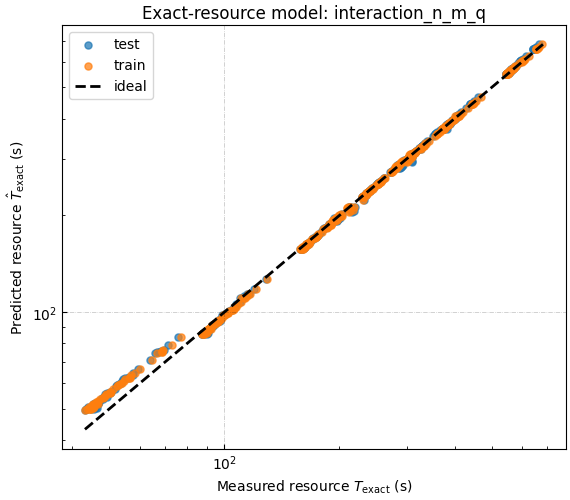

Best measured-time resource model:
  T_exact = 13.7558 + 3.55874 N + 0.00210949 M + 0.00253714 Q + 0.000710092 N M + -1.6388e-07 N Q + -1.95075e-08 M Q


In [6]:
# Proxy vs measured-time calibration
calibration_df = exact_df.loc[:, [
    'instance', 'split', 'N', 'M', 'Q',
    'T_exact_proxy', 'T_exact', 'training_cost', 'sampling_cost'
]].copy()
calibration_df = calibration_df.dropna(subset=['T_exact_proxy', 'T_exact'])
calibration_df = calibration_df[
    (pd.to_numeric(calibration_df['T_exact_proxy'], errors='coerce') > 0)
    & (pd.to_numeric(calibration_df['T_exact'], errors='coerce') > 0)
].copy()

proxy_values = calibration_df['T_exact_proxy'].to_numpy(dtype=float)
exact_values = calibration_df['T_exact'].to_numpy(dtype=float)

alpha_origin = float(np.dot(proxy_values, exact_values) / np.dot(proxy_values, proxy_values))
alpha_affine, beta_affine = np.polyfit(proxy_values, exact_values, deg=1)
log_slope, log_intercept = np.polyfit(np.log(proxy_values), np.log(exact_values), deg=1)
log_prefactor = float(np.exp(log_intercept))

proxy_grid = np.geomspace(proxy_values.min(), proxy_values.max(), 200)
origin_line = alpha_origin * proxy_grid
affine_line = alpha_affine * proxy_grid + beta_affine
power_line = log_prefactor * proxy_grid**log_slope

calibration_summary_df = pd.DataFrame([
    {
        'model': 'through_origin',
        'expression': f'T_exact ≈ {alpha_origin:.6g} · T_proxy',
        'alpha': alpha_origin,
        'beta': 0.0,
        'power_slope': 1.0,
    },
    {
        'model': 'affine',
        'expression': f'T_exact ≈ {alpha_affine:.6g} · T_proxy + {beta_affine:.6g}',
        'alpha': float(alpha_affine),
        'beta': float(beta_affine),
        'power_slope': 1.0,
    },
    {
        'model': 'power_law',
        'expression': f'T_exact ≈ {log_prefactor:.6g} · T_proxy^{log_slope:.6g}',
        'alpha': log_prefactor,
        'beta': 0.0,
        'power_slope': float(log_slope),
    },
])
calibration_summary_df.to_csv(OUTPUT_ROOT / 'proxy_exact_calibration_summary.csv', index=False)

display(calibration_summary_df)

plt.figure(figsize=(7.5, 5.5))
plt.scatter(calibration_df['T_exact_proxy'], calibration_df['T_exact'], s=18, alpha=0.18, color='0.45', label='Exact settings')
plt.plot(proxy_grid, origin_line, color='tab:blue', linewidth=2.2, label='Through-origin scale')
plt.plot(proxy_grid, power_line, color='tab:green', linewidth=2.0, linestyle='--', label='Power-law fit')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Proxy resource $(T_{\mathrm{proxy}} = c N M t_{\mathrm{shot}} + Q t_{\mathrm{shot}})$')
plt.ylabel(r'Measured time $(T_{\mathrm{exact}} = T_{\mathrm{train}} + T_{\mathrm{sample}})$')
plt.title(f'Proxy-to-measured calibration: {GRAPH_TYPE}, n={NUM_NODES}')
plt.grid(alpha=0.25)
plt.legend()
save_current_plot('proxy_vs_exact_calibration', PLOT_DIR)
plt.show()

print('Recommended global scale to map proxy onto measured-time units:')
print(f'  T_exact ≈ {alpha_origin:.6g} · T_proxy')

# Exact-resource model selection: predict measured time directly from N, M, and Q.
exact_resource_model_summary_df, exact_resource_model_prediction_df = fit_exact_resource_models(
    exact_df,
    target_col='T_exact',
)
exact_resource_model_summary_df.to_csv(OUTPUT_ROOT / 'exact_resource_model_summary.csv', index=False)
exact_resource_model_prediction_df.to_csv(OUTPUT_ROOT / 'exact_resource_model_predictions.csv', index=False)

display(exact_resource_model_summary_df)
plot_exact_resource_model_predictions(
    exact_resource_model_prediction_df,
    exact_resource_model_summary_df,
    plot_dir=PLOT_DIR,
    filename='exact_resource_model_predictions',
)

if not exact_resource_model_summary_df.empty:
    print('Best measured-time resource model:')
    print('  ' + exact_resource_model_summary_df.iloc[0]['expression'])


In [7]:
# Run stochastic-benchmark on the augmented proxy resource axis
ws_results = run_stochastic_benchmark_pss(
    augmented_proxy_frontier_df,
    output_dir=AUGMENTED_PROXY_WINDOW_STICKER_DIR,
    codebooks=ws_codebooks,
    response_col='BestApproximationRatio',
    resource_col='T',
    response_key='Response',
    bootstrap_range=BS_BOOTSTRAP_RANGE,
    train_test_split=TRAIN_TEST_SPLIT_FRACTION,
    clear_checkpoints=True,
)

virtual_best_df = ws_results['virtual_best_df']
projection_summary_df = ws_results['projection_summary_df']
window_sticker_summary_df = ws_results['window_sticker_summary_df']

resource_axis_summary_df = pd.DataFrame([
    {
        'axis': 'T_proxy_aug',
        'formula': 'T_proxy_aug = N M t_shot + Q t_shot + T_iter_total',
        'T_iter_total source': 'runtime_train_wallclock',
        'frontier': 'augmented_proxy_frontier_df',
        'rows': len(augmented_proxy_frontier_df),
        'budget_points': augmented_proxy_frontier_df['T'].nunique(),
        'resource_min': augmented_proxy_frontier_df['T'].min(),
        'resource_max': augmented_proxy_frontier_df['T'].max(),
    },
])

print('Augmented-proxy raw exp_raw files written:', len(ws_results['written_files']))
display(virtual_best_df)
display(window_sticker_summary_df)
display(resource_axis_summary_df)


  0%|          | 0/408 [00:00<?, ?it/s]/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:120: UserWarning: Dataframe has duplicate resources. Dropping duplicates, but consider re-running bootstrap
  warnings.warn(warn_str)
/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:120: UserWarning: Dataframe has duplicate resources. Dropping duplicates, but consider re-running bootstrap
  warnings.warn(warn_str)
/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:120: UserWarning: Dataframe has duplicate resources. Dropping duplicates, but consider re-running bootstrap
  warnings.warn(warn_str)
/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:120: UserWarning: Dataframe has duplicate resources. Dropping duplicates, but consider re-running bootstrap
  warnings.warn(warn_str)
/mnt/c/Users/rames102/Desktop/stochastic-benchmark/src/interpolate.py:120: UserWarning: Dataframe has duplicate resources. Dropping duplicates, b

Measured-time raw exp_raw files written: 30


,resource,strategy_code,simulation_code,N,M,Q,p,index,response,response_lower,response_upper,count,strategy,simulation_method
0,42.150709,0.0,0.0,10.0,10.0,100.0,5.0,0,0.802886,0.802886,0.802886,1,FA_PP_opt,MPSAer
1,42.395108,0.0,0.0,10.0,10.0,100.0,5.0,1,0.852803,0.852803,0.852803,2,FA_PP_opt,MPSAer
2,42.395108,0.0,0.0,10.0,10.0,100.0,5.0,2,0.852803,0.852803,0.852803,2,FA_PP_opt,MPSAer
3,42.640923,0.0,0.0,10.0,10.0,200.0,5.0,3,0.832618,0.832618,0.832618,3,FA_PP_opt,MPSAer
4,42.888164,0.0,0.0,10.0,10.0,250.0,5.0,4,0.848665,0.848665,0.848665,2,FA_PP_opt,MPSAer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
765,1734.941387,0.0,0.0,20.0,50.0,10000.0,5.0,765,0.896974,0.896974,0.896974,1,FA_PP_opt,MPSAer
766,1745.000929,0.0,0.0,20.0,50.0,10000.0,5.0,766,0.896974,0.896974,0.896974,1,FA_PP_opt,MPSAer
767,1745.000929,0.0,0.0,20.0,50.0,10000.0,5.0,767,0.896974,0.896974,0.896974,1,FA_PP_opt,MPSAer
768,1775.530873,0.0,0.0,20.0,50.0,10000.0,5.0,768,0.896974,0.896974,0.896974,1,FA_PP_opt,MPSAer


,resource,strategy,simulation_method,N,M,Q,p,response,response_lower,response_upper
0,42.150709,FA_PP_opt,MPSAer,10.0,10.0,100.000000,5.0,0.802886,0.802886,0.802886
1,42.640923,FA_PP_opt,MPSAer,10.0,10.0,200.000000,5.0,0.832618,0.832618,0.832618
2,42.888164,FA_PP_opt,MPSAer,10.0,10.0,250.000000,5.0,0.848665,0.848665,0.848665
3,42.888164,FA_PP_opt,MPSAer,10.0,10.0,250.000000,5.0,0.848665,0.848665,0.848665
4,43.136838,FA_PP_opt,MPSAer,10.0,10.0,266.666667,5.0,0.824429,0.824429,0.824429
...,...,...,...,...,...,...,...,...,...,...
734,1037.095359,FA_PP_opt,MPSAer,150.0,200.0,500.000000,5.0,0.822878,0.822878,0.822878
735,1037.095359,FA_PP_opt,MPSAer,150.0,200.0,500.000000,5.0,0.822878,0.822878,0.822878
736,1043.108648,FA_PP_opt,MPSAer,150.0,200.0,2500.000000,5.0,0.822878,0.822878,0.822878
737,1073.702149,FA_PP_opt,MPSAer,150.0,200.0,10000.000000,5.0,0.822878,0.822878,0.822878


,axis,frontier,rows,budget_points,resource_min,resource_max
0,T_exact,exact_frontier_df,12240,552,40.01356,12898.86734


## Window Sticker on Augmented Proxy Resource (`T_proxy_aug`)

All Window Sticker results below use `T_proxy_aug = N M t_shot + Q t_shot + T_iter_total` as the resource coordinate. `T_iter_total` comes from the measured training/iteration wallclock already stored in the experiment output, so this does not require rerunning the experiment.


,strategy,simulation_method,p,T,response_mean,response_std,response_min,response_max,N_mean,M_mean,Q_mean,training_cost_mean,sampling_cost_mean,training_cost_proxy_mean,sampling_cost_proxy_mean,T_exact_mean,T_exact_proxy_mean,n_instances,n_candidates
0,FA_PP_opt,MPSAer,5,40.013560,0.848997,0.000000,0.848997,0.848997,10.0,10.000000,100.000000,39.659354,0.238705,0.000250,0.000250,39.898058,0.000500,1,1
1,FA_PP_opt,MPSAer,5,40.245566,0.854217,0.000000,0.854217,0.854217,10.0,10.000000,250.000000,39.659354,0.596762,0.000250,0.000625,40.256115,0.000875,1,1
2,FA_PP_opt,MPSAer,5,40.949689,0.860061,0.000000,0.860061,0.860061,10.0,10.000000,500.000000,39.659354,1.193523,0.000250,0.001250,40.852877,0.001500,1,1
3,FA_PP_opt,MPSAer,5,42.150709,0.860061,0.000000,0.860061,0.860061,10.0,10.000000,1000.000000,39.659354,2.387047,0.000250,0.002500,42.046401,0.002750,1,1
4,FA_PP_opt,MPSAer,5,42.640923,0.814315,0.024126,0.797255,0.831375,10.0,10.000000,100.000000,42.420695,0.225353,0.000250,0.000250,42.646048,0.000500,2,2
5,FA_PP_opt,MPSAer,5,42.888164,0.833277,0.029730,0.775725,0.869987,10.0,37.142857,135.714286,42.558756,0.375746,0.000929,0.000339,42.934503,0.001268,7,7
6,FA_PP_opt,MPSAer,5,43.136838,0.832384,0.028995,0.782107,0.861518,10.0,41.666667,175.000000,42.765789,0.407404,0.001042,0.000438,43.173193,0.001479,6,6
7,FA_PP_opt,MPSAer,5,43.386954,0.834101,0.037152,0.756710,0.871694,10.0,18.636364,190.909091,42.950426,0.440017,0.000466,0.000477,43.390442,0.000943,8,11
8,FA_PP_opt,MPSAer,5,43.638521,0.827668,0.038233,0.761378,0.879281,10.0,41.944444,205.555556,43.048470,0.611527,0.001049,0.000514,43.659997,0.001563,12,18
9,FA_PP_opt,MPSAer,5,43.891545,0.832157,0.029217,0.752243,0.887794,10.0,32.954545,227.272727,43.308904,0.569591,0.000824,0.000568,43.878495,0.001392,16,22


,resource,strategy_code,simulation_code,N,M,Q,p,response,n_instances,n_virtual_best_rows,strategy,simulation_method
0,40.013560,0.0,0.0,10.0,10.000000,100.000000,5.0,0.848997,1,1,FA_PP_opt,MPSAer
1,40.245566,0.0,0.0,10.0,10.000000,250.000000,5.0,0.854217,1,1,FA_PP_opt,MPSAer
2,40.949689,0.0,0.0,10.0,10.000000,500.000000,5.0,0.860061,1,1,FA_PP_opt,MPSAer
3,40.949689,0.0,0.0,10.0,10.000000,500.000000,5.0,0.860061,1,1,FA_PP_opt,MPSAer
4,42.150709,0.0,0.0,10.0,10.000000,1000.000000,5.0,0.860061,1,1,FA_PP_opt,MPSAer
5,42.640923,0.0,0.0,10.0,10.000000,100.000000,5.0,0.814315,2,2,FA_PP_opt,MPSAer
6,42.888164,0.0,0.0,10.0,10.000000,264.285714,5.0,0.838482,7,7,FA_PP_opt,MPSAer
7,42.888164,0.0,0.0,10.0,10.000000,264.285714,5.0,0.838482,7,7,FA_PP_opt,MPSAer
8,43.136838,0.0,0.0,10.0,41.666667,175.000000,5.0,0.832384,6,6,FA_PP_opt,MPSAer
9,43.136838,0.0,0.0,10.0,41.666667,175.000000,5.0,0.832384,6,6,FA_PP_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,boots,strategy,simulation_method
0,40.013560,0.0,0.0,10.0,10.000000,100.000000,5.0,10.000000,FA_PP_opt,MPSAer
1,40.245566,0.0,0.0,10.0,10.000000,250.000000,5.0,10.000000,FA_PP_opt,MPSAer
2,40.949689,0.0,0.0,10.0,10.000000,500.000000,5.0,40.000000,FA_PP_opt,MPSAer
3,40.949689,0.0,0.0,10.0,10.000000,500.000000,5.0,10.000000,FA_PP_opt,MPSAer
4,42.150709,0.0,0.0,10.0,10.000000,1000.000000,5.0,10.000000,FA_PP_opt,MPSAer
5,42.640923,0.0,0.0,10.0,10.000000,100.000000,5.0,10.000000,FA_PP_opt,MPSAer
6,42.888164,0.0,0.0,10.0,10.000000,264.285714,5.0,18.571429,FA_PP_opt,MPSAer
7,42.888164,0.0,0.0,10.0,10.000000,264.285714,5.0,10.000000,FA_PP_opt,MPSAer
8,43.136838,0.0,0.0,10.0,41.666667,175.000000,5.0,10.000000,FA_PP_opt,MPSAer
9,43.136838,0.0,0.0,10.0,41.666667,175.000000,5.0,30.000000,FA_PP_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,boots,strategy,simulation_method
0,40.013560,0.0,0.0,10.0,85.119294,1854.194432,5.0,10.000000,FA_PP_opt,MPSAer
1,40.245566,0.0,0.0,10.0,85.436864,1867.276555,5.0,10.000000,FA_PP_opt,MPSAer
2,40.949689,0.0,0.0,10.0,86.391862,1906.921855,5.0,40.000000,FA_PP_opt,MPSAer
3,40.949689,0.0,0.0,10.0,86.391862,1906.921855,5.0,10.000000,FA_PP_opt,MPSAer
4,42.150709,0.0,0.0,10.0,87.990887,1974.333150,5.0,10.000000,FA_PP_opt,MPSAer
5,42.640923,0.0,0.0,10.0,88.632965,2001.767406,5.0,10.000000,FA_PP_opt,MPSAer
6,42.888164,0.0,0.0,10.0,88.954515,2015.585547,5.0,18.571429,FA_PP_opt,MPSAer
7,42.888164,0.0,0.0,10.0,88.954515,2015.585547,5.0,10.000000,FA_PP_opt,MPSAer
8,43.136838,0.0,0.0,10.0,89.276397,2029.471142,5.0,10.000000,FA_PP_opt,MPSAer
9,43.136838,0.0,0.0,10.0,89.276397,2029.471142,5.0,30.000000,FA_PP_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,response,response_lower,response_upper,strategy,simulation_method
0,40.013560,0.0,0.0,10.0,10.000000,100.000000,5.0,0.848997,0.848997,0.848997,FA_PP_opt,MPSAer
1,40.245566,0.0,0.0,10.0,10.000000,250.000000,5.0,0.854217,0.854217,0.854217,FA_PP_opt,MPSAer
2,40.949689,0.0,0.0,10.0,10.000000,500.000000,5.0,0.860061,0.860061,0.860061,FA_PP_opt,MPSAer
3,40.949689,0.0,0.0,10.0,10.000000,500.000000,5.0,0.860061,0.860061,0.860061,FA_PP_opt,MPSAer
4,42.150709,0.0,0.0,10.0,10.000000,1000.000000,5.0,0.860061,0.860061,0.860061,FA_PP_opt,MPSAer
5,42.640923,0.0,0.0,10.0,10.000000,100.000000,5.0,0.814315,0.814315,0.814315,FA_PP_opt,MPSAer
6,42.888164,0.0,0.0,10.0,37.142857,135.714286,5.0,0.833277,0.833277,0.833277,FA_PP_opt,MPSAer
7,42.888164,0.0,0.0,10.0,37.142857,135.714286,5.0,0.833277,0.833277,0.833277,FA_PP_opt,MPSAer
8,43.136838,0.0,0.0,10.0,41.666667,175.000000,5.0,0.832384,0.832384,0.832384,FA_PP_opt,MPSAer
9,43.136838,0.0,0.0,10.0,41.666667,175.000000,5.0,0.832384,0.832384,0.832384,FA_PP_opt,MPSAer


...

,resource,strategy_code,simulation_code,N,M,Q,p,response,response_lower,response_upper,strategy,simulation_method
0,42.150709,0.0,0.0,10.0,10.000000,100.000000,5.0,0.802886,0.802886,0.802886,FA_PP_opt,MPSAer
1,42.640923,0.0,0.0,10.0,10.000000,200.000000,5.0,0.832618,0.832618,0.832618,FA_PP_opt,MPSAer
2,42.888164,0.0,0.0,10.0,10.000000,250.000000,5.0,0.848665,0.848665,0.848665,FA_PP_opt,MPSAer
3,42.888164,0.0,0.0,10.0,10.000000,250.000000,5.0,0.848665,0.848665,0.848665,FA_PP_opt,MPSAer
4,43.136838,0.0,0.0,10.0,10.000000,266.666667,5.0,0.824429,0.824429,0.824429,FA_PP_opt,MPSAer
5,43.136838,0.0,0.0,10.0,10.000000,266.666667,5.0,0.824429,0.824429,0.824429,FA_PP_opt,MPSAer
6,43.386954,0.0,0.0,10.0,10.000000,258.333333,5.0,0.829616,0.829616,0.829616,FA_PP_opt,MPSAer
7,43.386954,0.0,0.0,10.0,10.000000,258.333333,5.0,0.829616,0.829616,0.829616,FA_PP_opt,MPSAer
8,43.386954,0.0,0.0,10.0,10.000000,258.333333,5.0,0.829616,0.829616,0.829616,FA_PP_opt,MPSAer
9,43.638521,0.0,0.0,10.0,18.571429,200.000000,5.0,0.822932,0.822932,0.822932,FA_PP_opt,MPSAer


,parameter,expression,coeff_0,coeff_1,coeff_2
0,N,N(T) = exp(-4.394 + 2.193 log(T) - 0.142 log(T...,-4.394088,2.193226,-0.141979
1,M,M(T) = exp(0.1654 + 1.675 log(T) - 0.1396 log(...,0.165409,1.674617,-0.139554
2,Q,Q(T) = exp(0.2324 + 2.736 log(T) - 0.2059 log(...,0.232386,2.736327,-0.205879


,graph type,num nodes,resource axis,fitted strategy,fitted p,fitted N,fitted M,fitted Q,fitted response
0,heavy_hex,144,T_exact,FA_PP_opt,5.0,150.0,500.0,10000.0,0.888431


,dataset,n_rows,resource_min,resource_max
0,train exact frontier,8160,40.013560,12898.867340
1,test exact frontier,4080,42.150709,1903.086336
2,train virtual-best lookup,929,40.013560,12898.867340
3,fitted prescription test,739,42.150709,1124.529011


Actionable prescription equations on T_exact:
  N(T) = exp(-4.394 + 2.193 log(T) - 0.142 log(T)^2)
  M(T) = exp(0.1654 + 1.675 log(T) - 0.1396 log(T)^2)
  Q(T) = exp(0.2324 + 2.736 log(T) - 0.2059 log(T)^2)
Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/cost_vs_best_approximation_ratio_exact_resource.pdf and .png


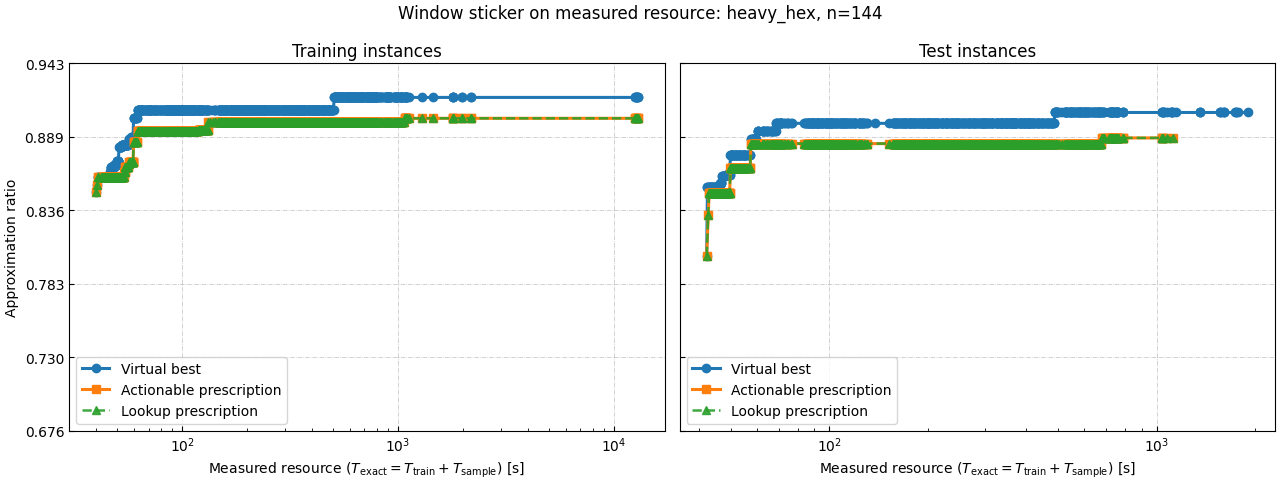

,strategy,T,ApproximationRatio
0,FA_PP_opt,40.013560,0.848997
1,FA_PP_opt,40.245566,0.854217
2,FA_PP_opt,40.949689,0.860061
3,FA_PP_opt,42.150709,0.860061
4,FA_PP_opt,42.640923,0.814315
...,...,...,...
530,FA_PP_opt,2173.742826,0.759902
531,FA_PP_opt,12603.993057,0.807655
532,FA_PP_opt,12750.577807,0.797400
533,FA_PP_opt,12824.508242,0.785332


Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/per_method_cost_performance_exact_resource.pdf and .png


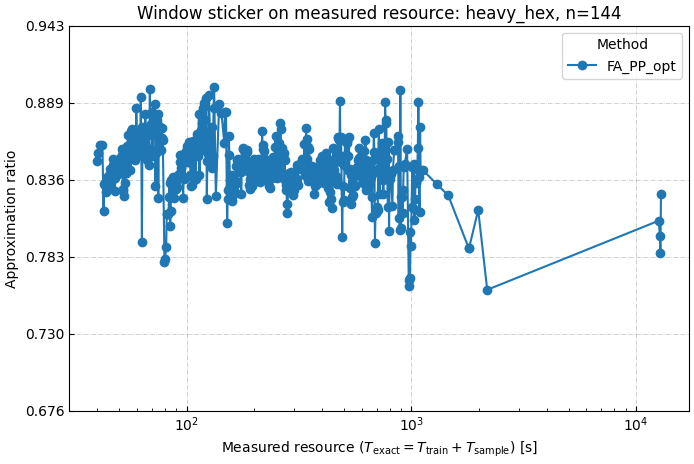

Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/monotone_envelope_comparison_exact_resource.pdf and .png


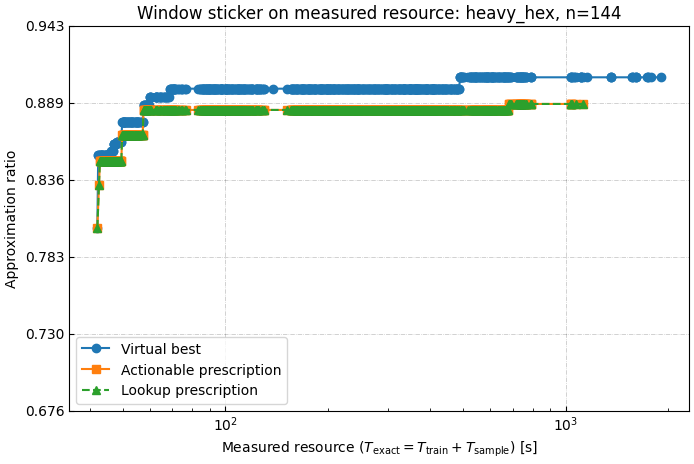

In [8]:
# Augmented-proxy resource summaries and plots
strategy_budget_df = build_strategy_budget_summary(augmented_proxy_frontier_df, split='train')
vb_train_lookup_df = ws_results['vb_train_lookup_df'].copy()
lookup_recipe_train_df = ws_results['recipe_train_df'].copy()
lookup_train_eval_df = ws_results['actionable_train_eval_df'].copy()
fitted_recipe_train_df = ws_results['fitted_recipe_df'].copy()
fitted_train_eval_df = ws_results['fitted_train_eval_df'].copy()
fitted_test_eval_df = ws_results['fitted_test_eval_df'].copy()
fitted_recipe_model_df = ws_results['fitted_recipe_model_df'].copy()
lookup_test_eval_df = window_sticker_summary_df.copy()

best_fitted_df = fitted_test_eval_df.sort_values(['response', 'resource'], ascending=[False, True]).reset_index(drop=True)
recommendation_summary = pd.DataFrame([
    {
        'graph type': GRAPH_TYPE,
        'num nodes': NUM_NODES,
        'resource axis': 'T_proxy_aug',
        'fitted strategy': best_fitted_df.iloc[0]['strategy'] if not best_fitted_df.empty else None,
        'fitted p': best_fitted_df.iloc[0]['p'] if not best_fitted_df.empty else None,
        'fitted N': best_fitted_df.iloc[0]['N'] if not best_fitted_df.empty else None,
        'fitted M': best_fitted_df.iloc[0]['M'] if not best_fitted_df.empty else None,
        'fitted Q': best_fitted_df.iloc[0]['Q'] if not best_fitted_df.empty else None,
        'fitted response': best_fitted_df.iloc[0]['response'] if not best_fitted_df.empty else None,
    }
])

display(strategy_budget_df.head(20))
display(vb_train_lookup_df.head(20))
display(lookup_recipe_train_df.head(20))
display(fitted_recipe_train_df.head(20))
display(lookup_train_eval_df.head(20))
display(fitted_train_eval_df.head(20))
display(fitted_test_eval_df.head(20))
display(fitted_recipe_model_df)
display(recommendation_summary)

resource_support_debug_df = pd.DataFrame([
    {
        'dataset': 'train augmented proxy frontier',
        'n_rows': len(augmented_proxy_frontier_df[augmented_proxy_frontier_df['split'].astype(str).eq('train')]),
        'resource_min': augmented_proxy_frontier_df.loc[augmented_proxy_frontier_df['split'].astype(str).eq('train'), 'T'].min(),
        'resource_max': augmented_proxy_frontier_df.loc[augmented_proxy_frontier_df['split'].astype(str).eq('train'), 'T'].max(),
    },
    {
        'dataset': 'test augmented proxy frontier',
        'n_rows': len(augmented_proxy_frontier_df[augmented_proxy_frontier_df['split'].astype(str).eq('test')]),
        'resource_min': augmented_proxy_frontier_df.loc[augmented_proxy_frontier_df['split'].astype(str).eq('test'), 'T'].min(),
        'resource_max': augmented_proxy_frontier_df.loc[augmented_proxy_frontier_df['split'].astype(str).eq('test'), 'T'].max(),
    },
    {
        'dataset': 'train virtual-best lookup',
        'n_rows': len(vb_train_lookup_df),
        'resource_min': vb_train_lookup_df['resource'].min() if not vb_train_lookup_df.empty else None,
        'resource_max': vb_train_lookup_df['resource'].max() if not vb_train_lookup_df.empty else None,
    },
    {
        'dataset': 'fitted prescription test',
        'n_rows': len(fitted_test_eval_df),
        'resource_min': fitted_test_eval_df['resource'].min() if not fitted_test_eval_df.empty else None,
        'resource_max': fitted_test_eval_df['resource'].max() if not fitted_test_eval_df.empty else None,
    },
])
display(resource_support_debug_df)

if not fitted_recipe_model_df.empty:
    print('Actionable prescription equations on T_proxy_aug:')
    for expression in fitted_recipe_model_df['expression'].dropna().tolist():
        print('  ' + expression)

shared_approx_ylim = compute_shared_approx_ylim(
    virtual_best_df.get('response'),
    fitted_test_eval_df.get('response'),
    lookup_test_eval_df.get('response'),
    vb_train_lookup_df.get('response'),
    lookup_train_eval_df.get('response'),
    fitted_train_eval_df.get('response'),
    strategy_budget_df.get('response_mean'),
    augmented_proxy_frontier_df.get('BestApproximationRatio'),
)
shared_approx_yticks = compute_shared_approx_yticks(shared_approx_ylim)

train_virtual_best_monotone_df = prepare_monotone_curve(vb_train_lookup_df)
lookup_train_monotone_df = prepare_monotone_curve(lookup_train_eval_df)
fitted_train_monotone_df = prepare_monotone_curve(fitted_train_eval_df)
test_virtual_best_monotone_df = prepare_monotone_curve(virtual_best_df)
lookup_test_monotone_df = prepare_monotone_curve(lookup_test_eval_df)
fitted_test_monotone_df = prepare_monotone_curve(fitted_test_eval_df)

xlabel = r'Resource $(T_{\mathrm{proxy}} = NMt_{\mathrm{shot}} + Qt_{\mathrm{shot}} + T_{\mathrm{iter,total}})$'
exact_ylabel = 'Approximation ratio'
main_title = f'Window sticker on augmented proxy resource: {GRAPH_TYPE}, n={NUM_NODES}'

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
plot_specs = [
    (axes[0], train_virtual_best_monotone_df, fitted_train_monotone_df, lookup_train_monotone_df, 'Training instances'),
    (axes[1], test_virtual_best_monotone_df, fitted_test_monotone_df, lookup_test_monotone_df, 'Test instances'),
]
for ax, vb_curve, fitted_curve, lookup_curve, title in plot_specs:
    ax.plot(vb_curve['resource'], vb_curve['response_monotone'], color='tab:blue', marker='o', linewidth=2.2, label='Virtual best')
    ax.plot(fitted_curve['resource'], fitted_curve['response_monotone'], color='tab:orange', marker='s', linewidth=2.2, label='Actionable prescription')
    ax.plot(lookup_curve['resource'], lookup_curve['response_monotone'], color='tab:green', marker='^', linewidth=1.8, linestyle='--', alpha=0.9, label='Lookup prescription')
    ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    apply_shared_approx_axis(ax, ylim=shared_approx_ylim, yticks=shared_approx_yticks)
    ax.legend()
axes[0].set_ylabel(exact_ylabel)
fig.suptitle(main_title)
fig.tight_layout()
save_current_plot('cost_vs_best_approximation_ratio_augmented_proxy_resource', PLOT_DIR)
plt.show()

augmented_proxy_candidate_parameter_df = augmented_proxy_frontier_df[
    augmented_proxy_frontier_df['split'].astype(str).eq('train')
].drop_duplicates(['instance', 'N', 'M', 'Q', 'T']).copy()

plot_parameter_prescriptions_by_resource(
    candidate_df=augmented_proxy_candidate_parameter_df,
    virtual_best_df=vb_train_lookup_df,
    lookup_df=lookup_train_eval_df,
    actionable_df=fitted_recipe_train_df,
    candidate_resource_col='T',
    curve_resource_col='resource',
    plot_dir=PLOT_DIR,
    filename='parameter_prescriptions_augmented_proxy_resource',
    title=f'Window sticker: {GRAPH_TYPE}, n={NUM_NODES}',
    xlabel=xlabel,
    parameter_ylims={
        'N': (8, 180),
        'M': (8, 1200),
        'Q': (80, 12000),
    },
    connect_points=True,
    show_virtual_best=False,
    show_lookup=False,
    actionable_marker=None,
)

per_method_curve_df = strategy_budget_df.loc[:, ['strategy', 'T', 'response_mean']].rename(columns={'response_mean': 'ApproximationRatio'})
display(per_method_curve_df)
plt.figure(figsize=(8, 5))
for strategy_name, group in per_method_curve_df.groupby('strategy'):
    plt.plot(group['T'], group['ApproximationRatio'], marker='o', label=strategy_name)
plt.xscale('log')
plt.xlabel(xlabel)
plt.ylabel(exact_ylabel)
apply_shared_approx_axis(ylim=shared_approx_ylim, yticks=shared_approx_yticks)
plt.title(main_title)
plt.grid(alpha=0.25)
plt.legend(title='Method')
save_current_plot('per_method_cost_performance_augmented_proxy_resource', PLOT_DIR)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(test_virtual_best_monotone_df['resource'], test_virtual_best_monotone_df['response_monotone'], marker='o', label='Virtual best')
plt.plot(fitted_test_monotone_df['resource'], fitted_test_monotone_df['response_monotone'], marker='s', label='Actionable prescription')
plt.plot(lookup_test_monotone_df['resource'], lookup_test_monotone_df['response_monotone'], marker='^', linestyle='--', label='Lookup prescription')
plt.xscale('log')
plt.xlabel(xlabel)
plt.ylabel(exact_ylabel)
apply_shared_approx_axis(ylim=shared_approx_ylim, yticks=shared_approx_yticks)
plt.title(main_title)
plt.grid(alpha=0.25)
plt.legend()
save_current_plot('monotone_envelope_comparison_augmented_proxy_resource', PLOT_DIR)
plt.show()


## Multi-Strategy Window Sticker Comparison

This section is written to work before and after the remaining strategies are run. Today, `MULTI_STRATEGY_RESULT_TAGS` can contain only the current `FA_PP_opt` result tag. Later, add one result tag per strategy root and rerun this section to get the Figure-6-style comparison: one actionable curve per strategy plus the envelope over strategies.


Loaded strategy roots:
  FA_PP_opt (MPSAer, p=5): /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded
Hyperparameter lookup rows: 1000


,method_label,strategy,simulation_method,p,T,response_mean,N_mean,M_mean,Q_mean,T_exact_proxy_mean,n_instances,n_candidates
0,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000500,0.817931,10.0,10.0,100.0,0.0005,20,20
1,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000503,0.817931,10.0,10.0,100.0,0.0005,20,20
2,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000507,0.817931,10.0,10.0,100.0,0.0005,20,20
3,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000510,0.817931,10.0,10.0,100.0,0.0005,20,20
4,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000514,0.817931,10.0,10.0,100.0,0.0005,20,20
5,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000517,0.817931,10.0,10.0,100.0,0.0005,20,20
6,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000520,0.817931,10.0,10.0,100.0,0.0005,20,20
7,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000524,0.817931,10.0,10.0,100.0,0.0005,20,20
8,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000527,0.817931,10.0,10.0,100.0,0.0005,20,20
9,"FA_PP_opt (MPSAer, p=5)",FA_PP_opt,MPSAer,5,0.000531,0.817931,10.0,10.0,100.0,0.0005,20,20


Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/multi_strategy_training_curves_envelope.pdf and .png


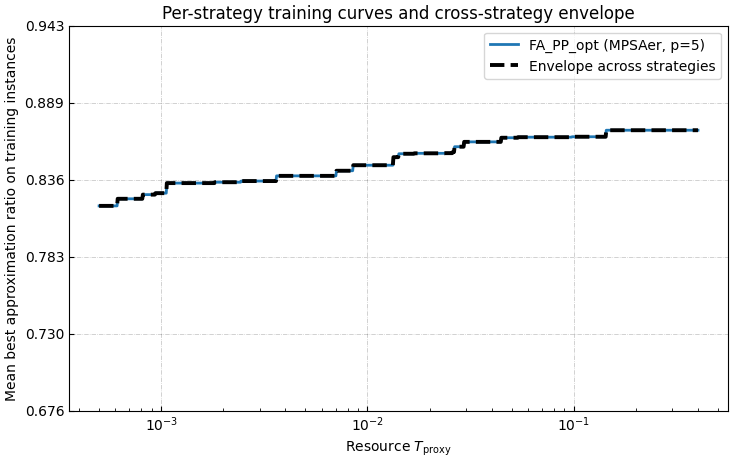

Saved: /mnt/c/Users/rames102/Desktop/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded/notebook_plots/multi_strategy_actionable_projection_envelope.pdf and .png


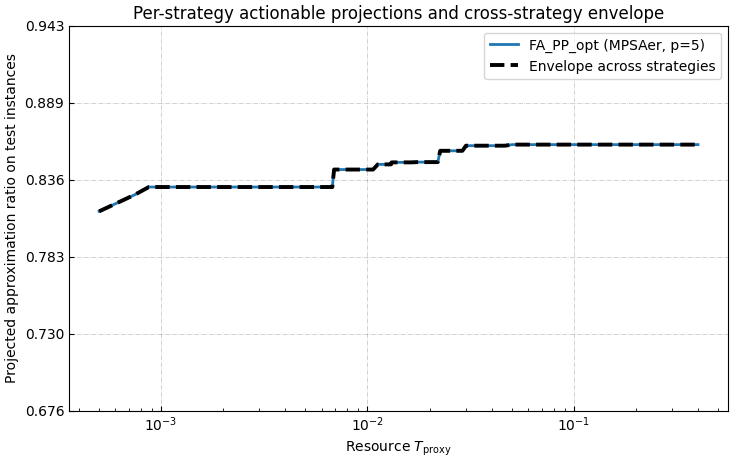

In [9]:
# Multi-strategy actionable PSS comparison
# Add future strategy result tags here after those campaigns finish.
MULTI_STRATEGY_RESULT_TAGS = [
    RESULT_TAG,
    # 'heavy_hex_144_LR_PP_opt_p5_expanded',
    # 'heavy_hex_144_FA_MPSAer_opt_p5_expanded',
    # 'heavy_hex_144_LR_MPSAer_opt_p5_expanded',
    # 'heavy_hex_144_PT_PP_AAA_p5_expanded',
]

PSS_RESULTS_BASE = OUTPUT_ROOT.parent

multi_strategy_summaries = load_multi_strategy_summaries(MULTI_STRATEGY_RESULT_TAGS, PSS_RESULTS_BASE)
print('Loaded strategy roots:')
for item in multi_strategy_summaries:
    print(f"  {item['method_label']}: {item['root']}")

multi_strategy_budget_df = concat_summary(multi_strategy_summaries, 'strategy_budget')
multi_actionable_lookup_df = concat_summary(multi_strategy_summaries, 'actionable_lookup')
multi_actionable_fit_df = concat_summary(multi_strategy_summaries, 'actionable_fit')
multi_window_sticker_df = concat_summary(multi_strategy_summaries, 'window_sticker')

training_strategy_curve_df = curve_from_training_summary(multi_strategy_budget_df)
training_strategy_envelope_df = cross_strategy_envelope(training_strategy_curve_df, 'T')

actionable_projection_curve_df = curve_from_window_summary(multi_window_sticker_df)
actionable_projection_envelope_df = cross_strategy_envelope(actionable_projection_curve_df, 'resource')

# This table is the direct answer to: which hyperparameters define the strategy curve at each budget?
hyperparameter_lookup_cols = [
    col for col in [
        'method_label', 'strategy', 'simulation_method', 'p', 'T', 'response_mean',
        'N_mean', 'M_mean', 'Q_mean', 'T_exact_proxy_mean', 'n_instances', 'n_candidates',
    ]
    if col in multi_actionable_lookup_df.columns
]
hyperparameter_lookup_df = multi_actionable_lookup_df.loc[:, hyperparameter_lookup_cols].copy() if hyperparameter_lookup_cols else pd.DataFrame()

if not hyperparameter_lookup_df.empty:
    hyperparameter_lookup_df.to_csv(OUTPUT_ROOT / 'multi_strategy_hyperparameter_lookup.csv', index=False)
if not training_strategy_envelope_df.empty:
    training_strategy_envelope_df.to_csv(OUTPUT_ROOT / 'multi_strategy_training_envelope.csv', index=False)
if not actionable_projection_envelope_df.empty:
    actionable_projection_envelope_df.to_csv(OUTPUT_ROOT / 'multi_strategy_actionable_projection_envelope.csv', index=False)

print('Hyperparameter lookup rows:', len(hyperparameter_lookup_df))
display(hyperparameter_lookup_df.head(20))

plot_method_curves(
    training_strategy_curve_df,
    training_strategy_envelope_df,
    resource_col='T',
    ylabel='Mean best approximation ratio on training instances',
    title='Per-strategy training curves and cross-strategy envelope',
    filename='multi_strategy_training_curves_envelope',
    plot_dir=PLOT_DIR,
    approx_ylim=shared_approx_ylim,
    approx_yticks=shared_approx_yticks,
)

plot_method_curves(
    actionable_projection_curve_df,
    actionable_projection_envelope_df,
    resource_col='resource',
    ylabel='Projected approximation ratio on test instances',
    title='Per-strategy actionable projections and cross-strategy envelope',
    filename='multi_strategy_actionable_projection_envelope',
    plot_dir=PLOT_DIR,
    approx_ylim=shared_approx_ylim,
    approx_yticks=shared_approx_yticks,
)


